In [1]:
from google.colab import drive
try:
  drive.mount('/content/drive')
  print("Kết nối thành công với gg drive")
except Exception as e:
  print(f"Đã xảy ra lỗi: {e}")

Mounted at /content/drive
Kết nối thành công với gg drive


=== BẮT ĐẦU XỬ LÝ ===
 [OK] Đã xử lý: Standard LSB
 [OK] Đã xử lý: Phase Coding
 [OK] Đã xử lý: Improved LSB

--- ĐANG VẼ BIỂU ĐỒ FONT 18 ---


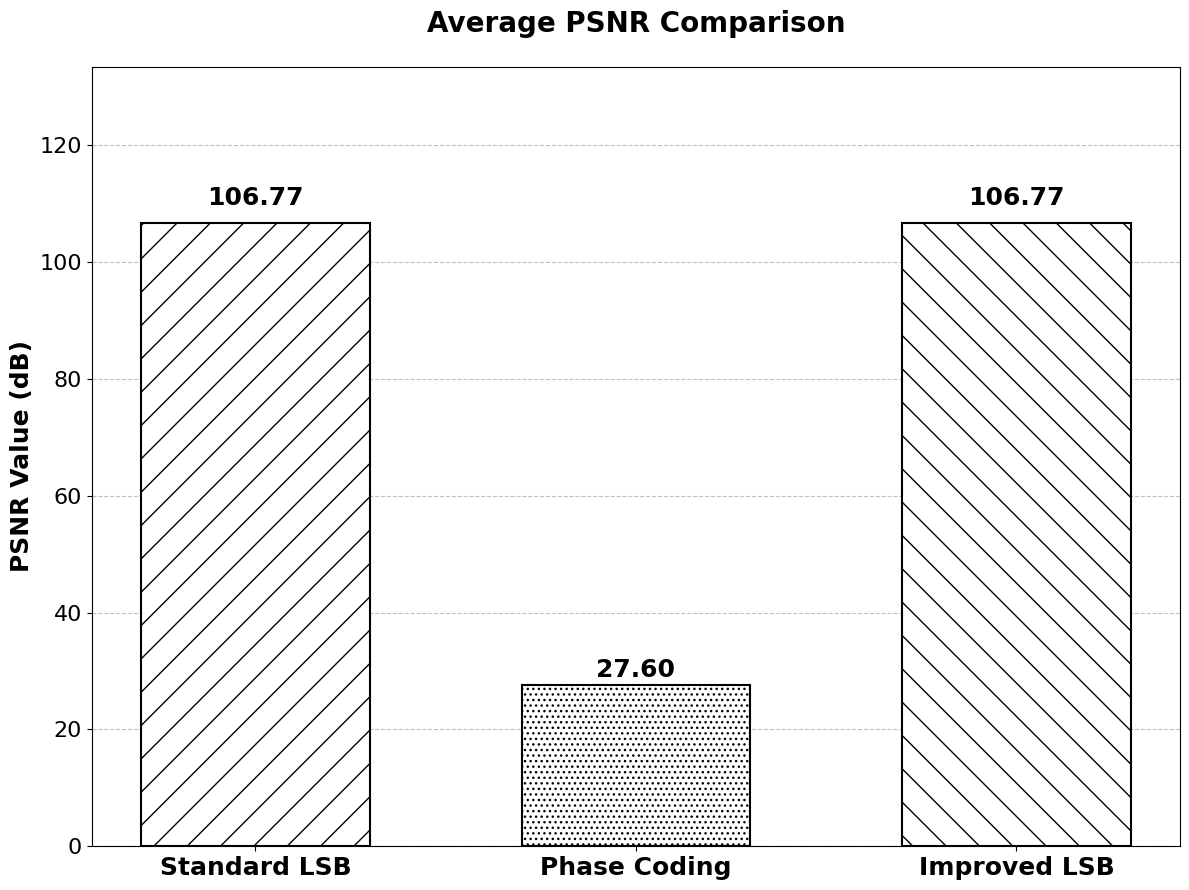

Đã lưu biểu đồ font lớn: Chart_PSNR_18pt.png


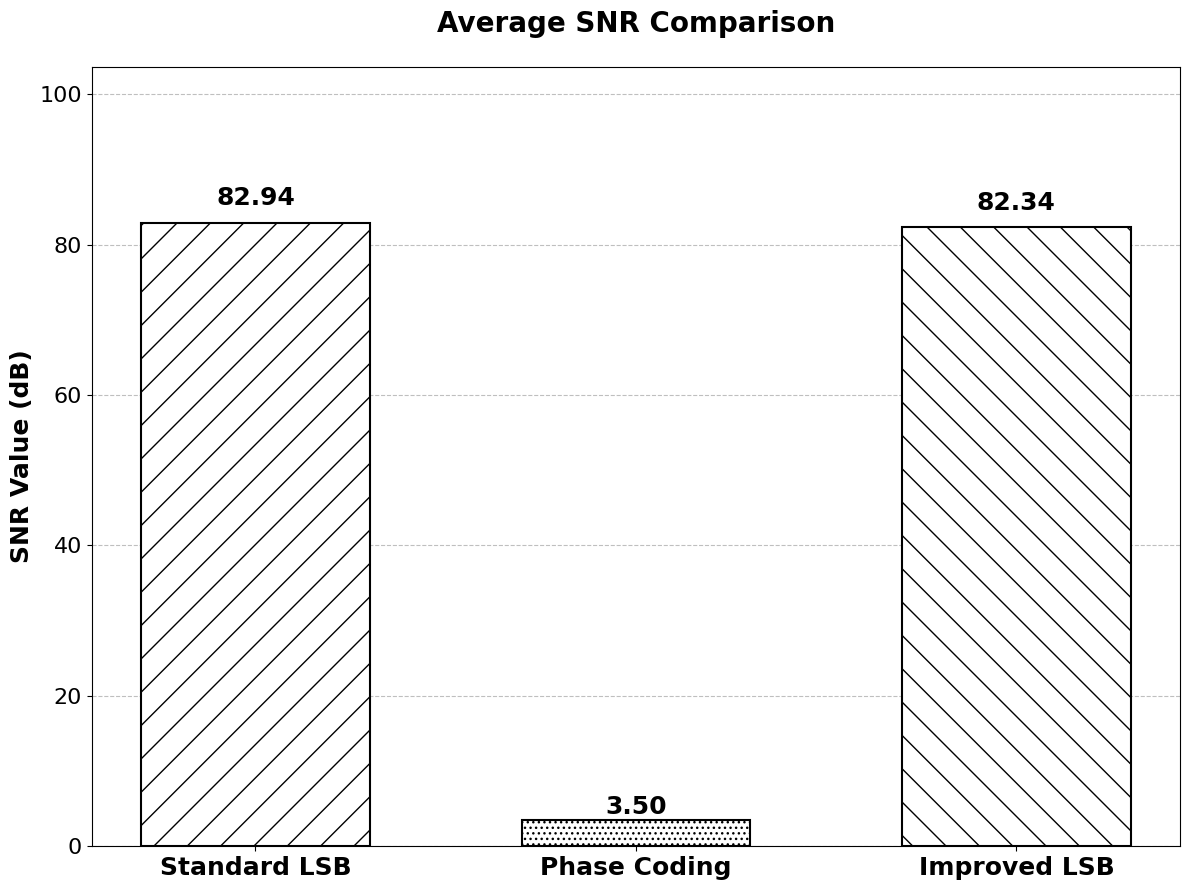

Đã lưu biểu đồ font lớn: Chart_SNR_18pt.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

files_map = {
    '/content/drive/MyDrive/HK1-20252026/ClassifyStego/data_model/lsb/log2025-10-10_00-07-55.csv': 'Standard LSB',
    '/content/drive/MyDrive/HK1-20252026/Steganography/Phase/ThucNghiem_PhaseCoding_2025-10-13_01-27-44_audio/log_2025-10-13_01-27-44.csv': 'Phase Coding',
    '/content/drive/MyDrive/HK1-20252026/Steganography/PSR-LSB/PSR-LSB_AUDIO_2025-11-21_20-41-03/detailed_log_2025-11-21 14:51:40.csv': 'Improved LSB'
}

results = []


for filename, method_name in files_map.items():
    if not os.path.exists(filename):
        print(f" [!] Không tìm thấy file: {filename}")
        continue
    try:
        try:
            df = pd.read_csv(filename, sep='\t')
            if len(df.columns) < 2: raise ValueError
        except:
            df = pd.read_csv(filename, sep=',')

        df.columns = df.columns.str.strip()
        df_clean = df.iloc[:-1]
        numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).copy()
        if numeric_cols.empty: continue
        numeric_cols.replace([np.inf, -np.inf], np.nan, inplace=True)
        file_average = numeric_cols.mean()
        file_average.name = method_name
        results.append(file_average)
        print(f" [OK] Đã xử lý: {method_name}")
    except Exception as e:
        print(f" [Err] Lỗi file {method_name}: {e}")

if results:
    final_df = pd.DataFrame(results)

    def plot_metric_grayscale_large_font(dataframe, metric_name, ylabel, filename_output):
        if metric_name not in dataframe.columns:
            return

        # Tăng kích thước figure để chứa font chữ lớn
        fig, ax = plt.subplots(figsize=(12, 9))

        values = dataframe[metric_name]
        labels = dataframe.index
        x = np.arange(len(labels))

        patterns = ['/', '...', '\\', 'x']
        bar_colors = ['white', 'white', 'white']

        # Vẽ cột
        bars = ax.bar(x, values, color=bar_colors, edgecolor='black', width=0.6, linewidth=1.5)

        # Áp dụng họa tiết
        for bar, pattern in zip(bars, patterns):
            bar.set_hatch(pattern)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + (height * 0.02),
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=18, fontweight='bold')

        ax.set_ylabel(ylabel, fontsize=18, fontweight='bold')
        ax.set_title(f'Average {metric_name} Comparison', fontsize=20, fontweight='bold', pad=25)

        ax.set_xticks(x)

        ax.set_xticklabels(labels, fontsize=18, fontweight='bold')

        # Tăng size cho các số đơn vị trên trục Y
        ax.tick_params(axis='y', labelsize=16)

        # Grid
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle='--', color='grey', alpha=0.5)

        # Giới hạn trục Y nới rộng để không chạm chữ
        ylim_max = values.max() * 1.25
        ax.set_ylim(0, ylim_max)

        plt.tight_layout()
        plt.savefig(filename_output, dpi=300)
        plt.show()
        print(f"Đã lưu biểu đồ font lớn: {filename_output}")

    # Gọi hàm vẽ
    print("\n--- ĐANG VẼ BIỂU ĐỒ FONT 18 ---")
    plot_metric_grayscale_large_font(final_df, 'PSNR', 'PSNR Value (dB)', 'Chart_PSNR_18pt.png')
    plot_metric_grayscale_large_font(final_df, 'SNR', 'SNR Value (dB)', 'Chart_SNR_18pt.png')

else:
    print("\n[!] Không có dữ liệu hợp lệ.")